# Tri intelligent des déchets


## 1. Récupérer le code depuis GitHub

In [2]:
REPO_URL = "https://github.com/nihmad/Trash-detection.git"

repo_dir = REPO_URL.rstrip("/").split("/")[-1].replace(".git", "")
!git clone $REPO_URL
%cd $repo_dir

Cloning into 'Trash-detection'...
remote: Enumerating objects: 25, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 25 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (25/25), 22.83 KiB | 22.83 MiB/s, done.
Resolving deltas: 100% (2/2), done.
/content/Trash-detection


## 2. Configurer l'accès Kaggle et télécharger TrashNet



In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("feyzazkefe/trashnet")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'trashnet' dataset.
Path to dataset files: /kaggle/input/trashnet


## 3. Localiser automatiquement le dossier des classes

In [4]:
from pathlib import Path

classes = {"cardboard", "glass", "metal", "paper", "plastic"}
raw_dir = None
for p in Path(path).rglob("*"):
    if p.is_dir():
        sous_dossiers = {c.name for c in p.iterdir() if c.is_dir()}
        if classes.issubset(sous_dossiers):
            raw_dir = p
            break

print("Dossier des données :", raw_dir)
if raw_dir is None:
    # Aide au diagnostic si la détection échoue
    print("Classes non trouvées. Contenu de path :")
    for sous in Path(path).rglob("*"):
        if sous.is_dir():
            print(" -", sous)

Dossier des données : /kaggle/input/trashnet/dataset-resized


## 4. Test rapide du pipeline (2 époques)



In [5]:
!python -m src.train --model cnn --epochs 2 --raw-dir "{raw_dir}"

2026-06-18 10:50:44.986976: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
10:51:07 | INFO    | src.dataset | Index construit : 2390 images, 5 classes.
10:51:07 | INFO    | src.dataset | Découpage : train=1672, val=359, test=359.
2026-06-18 10:51:08.682442: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1781779868.683920    7287 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
10:51:11 | INFO    | __main__ | Model: "custom_cnn"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━

## 5. Entraînement complet des deux modèles

In [6]:
!python -m src.train --model cnn --epochs 30 --raw-dir "{raw_dir}"
!python -m src.train --model resnet --epochs 15 --fine-tune-epochs 10 --raw-dir "{raw_dir}"

2026-06-18 10:51:50.568768: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
10:51:59 | INFO    | src.dataset | Index construit : 2390 images, 5 classes.
10:51:59 | INFO    | src.dataset | Découpage : train=1672, val=359, test=359.
2026-06-18 10:51:59.974736: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1781779919.976170    7718 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
10:52:02 | INFO    | __main__ | Model: "custom_cnn"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━

## 6. Évaluation et analyse des erreurs

In [7]:
!python -m src.evaluate --model cnn --raw-dir "{raw_dir}"
!python -m src.evaluate --model resnet --raw-dir "{raw_dir}"

2026-06-18 11:03:02.859534: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-18 11:03:06.706303: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1781780586.707840   11477 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
11:03:12 | INFO    | src.dataset | Index construit : 2390 images, 5 classes.
11:03:12 | INFO    | src.dataset | Découpage : train=1672, val=359, test=359.
2026-06-18 11:03:13.317859: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:47

## 7. Afficher les figures générées

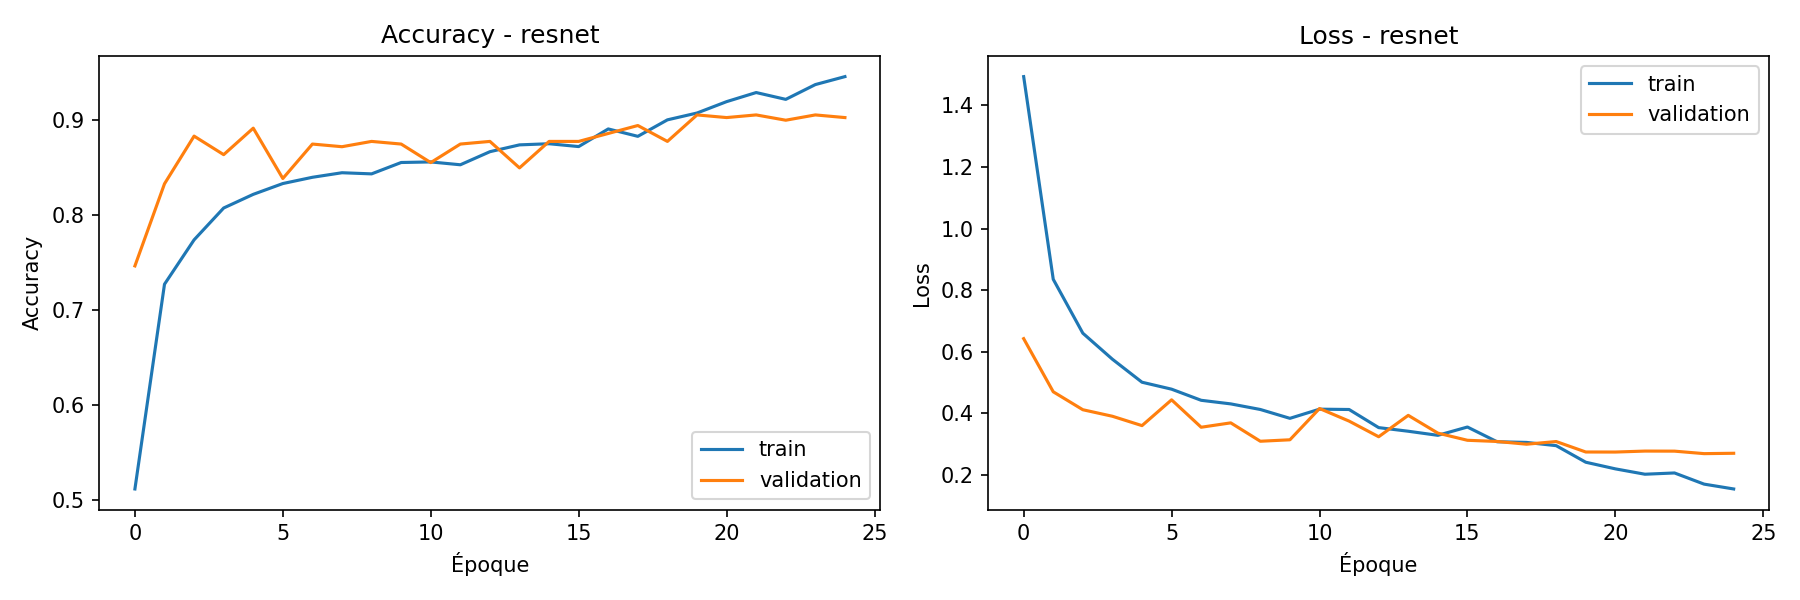

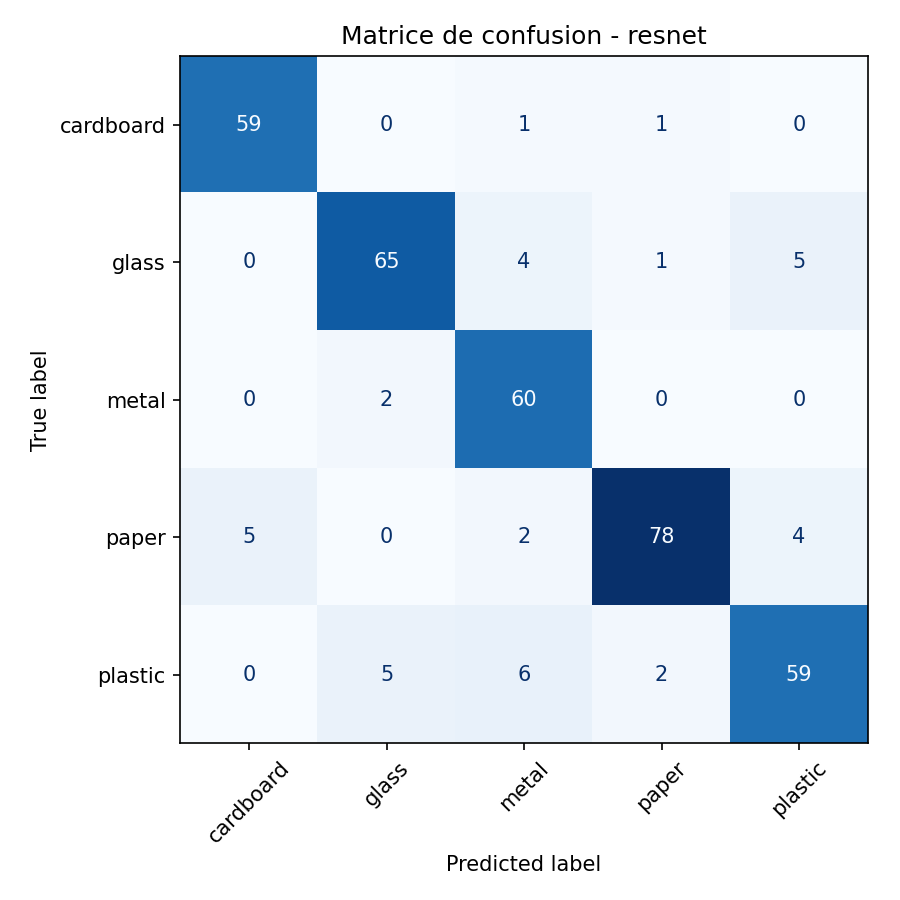

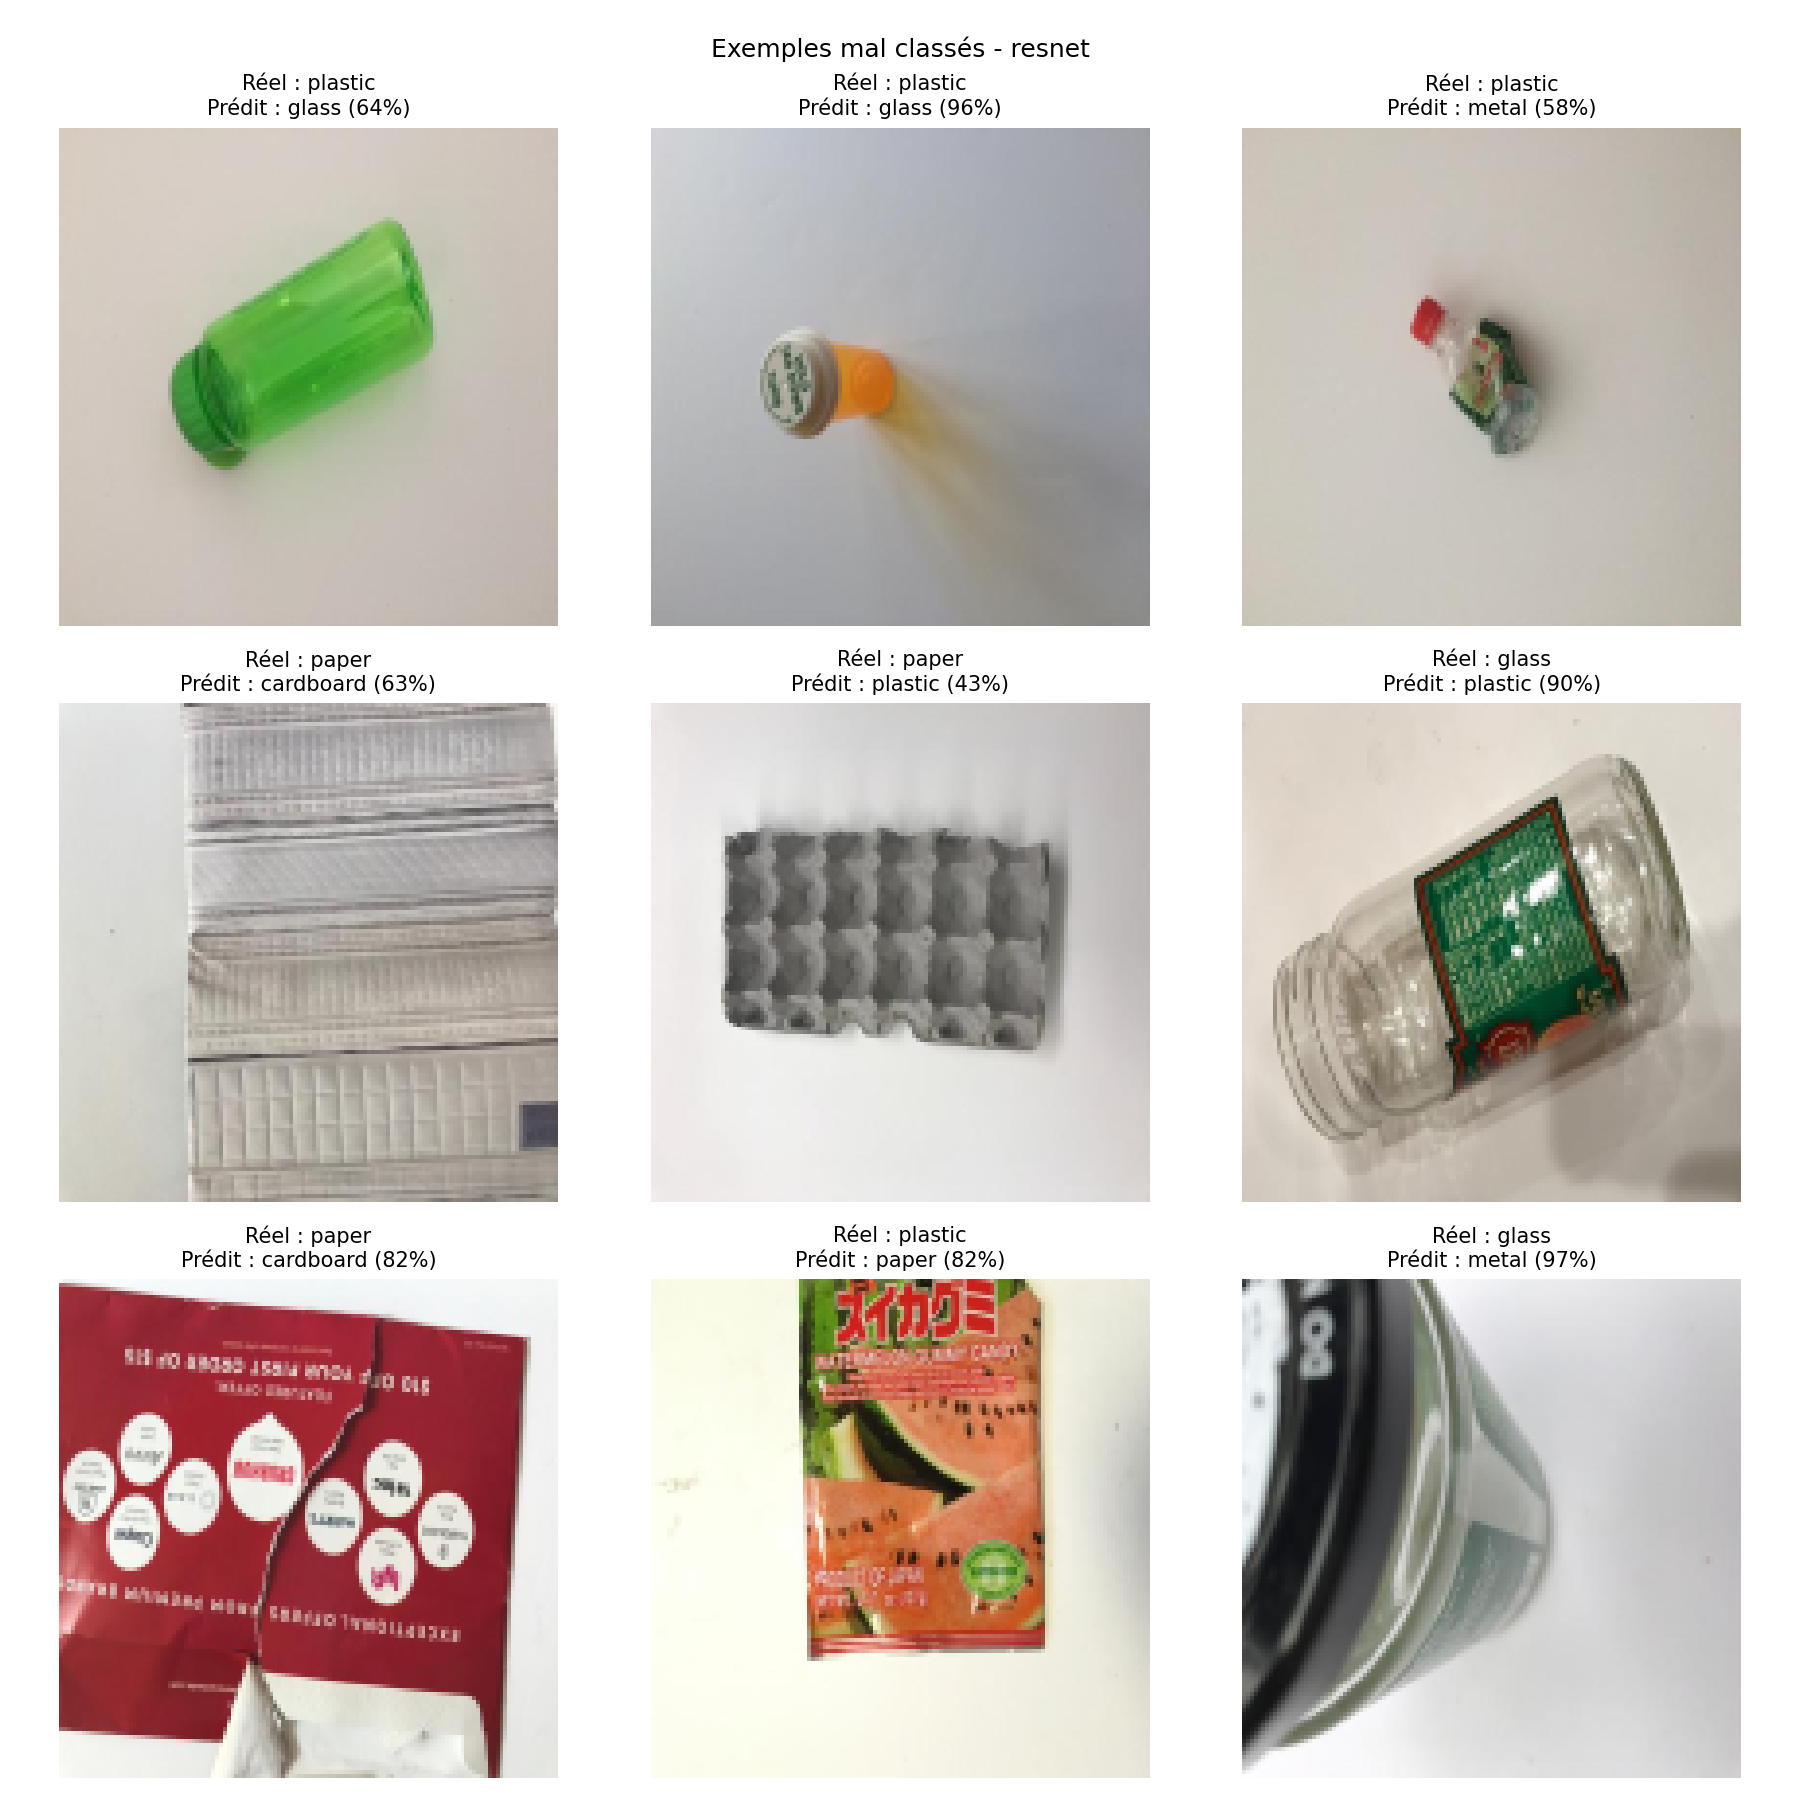

In [8]:
from IPython.display import Image, display

display(Image("reports/figures/resnet_training_curves.png"))
display(Image("reports/figures/resnet_confusion_matrix.png"))
display(Image("reports/figures/resnet_misclassified.png"))

## 8. Tester une prédiction



In [9]:
import numpy as np
import tensorflow as tf
from pathlib import Path
from src.utils import CLASS_NAMES, IMAGE_SIZE
from src.preprocessing import load_image, resize_image

model = tf.keras.models.load_model("models/resnet.keras")

# Choisis une image quelconque du dataset pour tester
image_path = next((raw_dir / "glass").glob("*.jpg"))
image = load_image(image_path)
batch = np.expand_dims(resize_image(image, IMAGE_SIZE).astype("float32"), axis=0)

probs = model.predict(batch, verbose=0)[0]
i = int(probs.argmax())
print(f"Classe prédite : {CLASS_NAMES[i]} ({probs[i]:.1%} de confiance)")

Classe prédite : metal (92.5% de confiance)


Sélectionne une ou plusieurs images à tester :


Saving 20260618_132159.jpg to 20260618_132159.jpg
Saving 20260618_132206.jpg to 20260618_132206.jpg
Saving 20260618_132230.jpg to 20260618_132230.jpg
Saving 20260618_132223.jpg to 20260618_132223.jpg
Saving 20260618_132148.jpg to 20260618_132148.jpg
Saving 20260618_132216.jpg to 20260618_132216.jpg


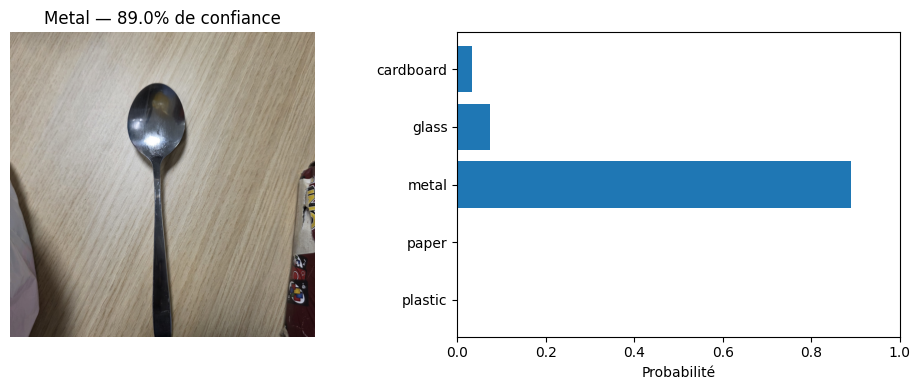

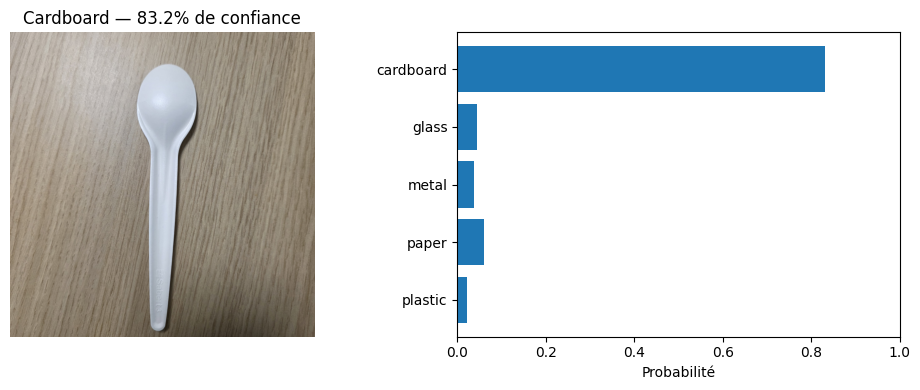

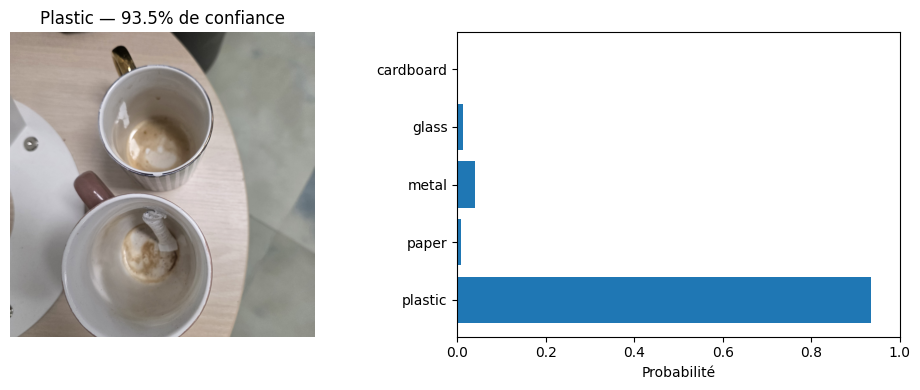

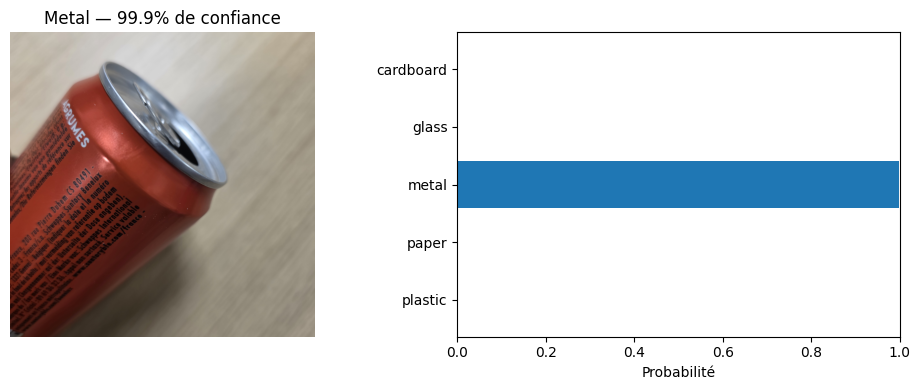

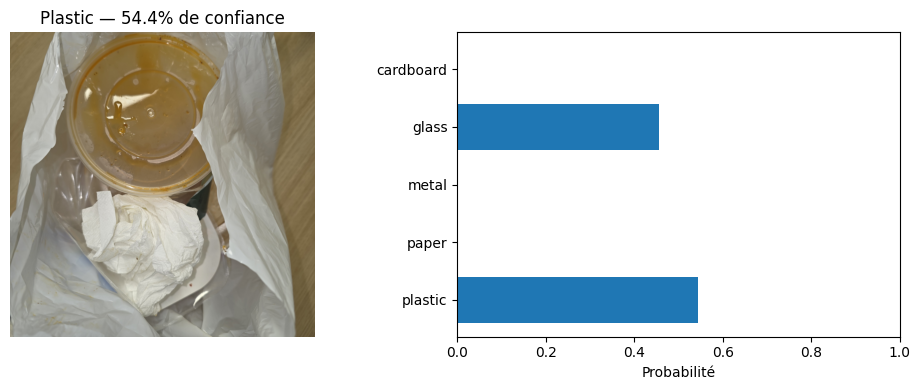

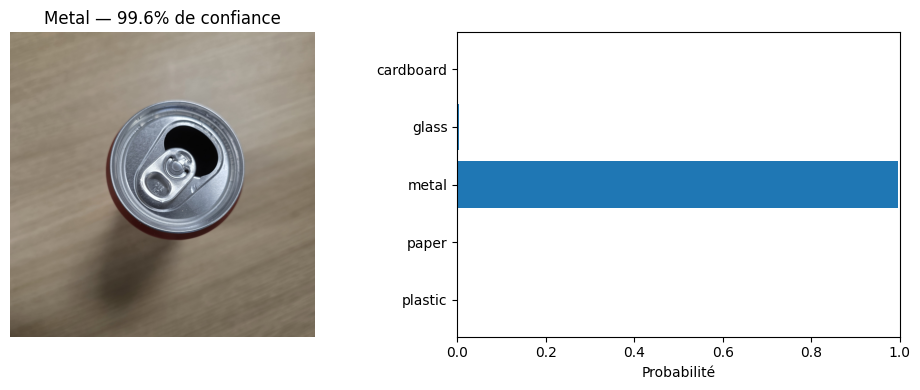

In [16]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from pathlib import Path
from google.colab import files

from src.utils import CLASS_NAMES, IMAGE_SIZE
from src.preprocessing import load_image, resize_image

# Modèle à utiliser : "resnet" ou "cnn"
MODEL_NAME = "resnet"
model = tf.keras.models.load_model(f"models/{MODEL_NAME}.keras")


def predire_et_afficher(image_path: str) -> None:
    """Affiche l'image, la classe prédite et la distribution des probabilités."""
    image = load_image(Path(image_path))
    batch = np.expand_dims(resize_image(image, IMAGE_SIZE).astype("float32"), axis=0)
    probs = model.predict(batch, verbose=0)[0]
    i = int(probs.argmax())

    fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(10, 4))
    ax_img.imshow(image)
    ax_img.axis("off")
    ax_img.set_title(f"{CLASS_NAMES[i].capitalize()} — {probs[i]:.1%} de confiance")

    ax_bar.barh(CLASS_NAMES, probs)
    ax_bar.set_xlim(0, 1)
    ax_bar.invert_yaxis()
    ax_bar.set_xlabel("Probabilité")
    plt.tight_layout()
    plt.show()


print("Sélectionne une ou plusieurs images à tester :")
uploaded = files.upload()
for nom_fichier in uploaded:
    predire_et_afficher(nom_fichier)